
# Module 25: DBSCAN & Hierarchical Clustering

This notebook is designed for hands-on practice.



## Dataset 1: Blob Dataset with Different Densities

This dataset contains clusters with different densities.
DBSCAN should behave differently for each cluster.


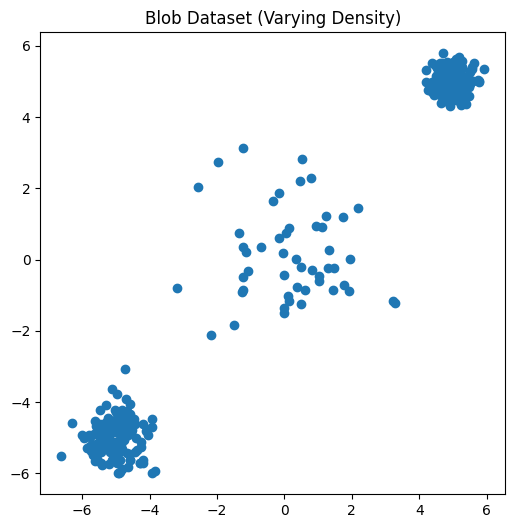

In [1]:
#Done for you
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X_blobs, _ = make_blobs(
    n_samples=[150, 50, 200],
    centers=[(-5, -5), (0, 0), (5, 5)],
    cluster_std=[0.5, 1.5, 0.3],
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_blobs[:,0], X_blobs[:,1])
plt.title("Blob Dataset (Varying Density)")
plt.show()


### TODO 1: Scaling

Scale the dataset using StandardScaler.

Think:
- Why is scaling important here?
- What happens if we skip scaling?


In [2]:
# TODO: Apply StandardScaler here
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_blobs_scaled = scaler.fit_transform(X_blobs)
# TODO: Apply StandardScaler here


### TODO 2: DBSCAN on Blob Dataset

Apply DBSCAN.
Experiment with different values of eps and min_samples.


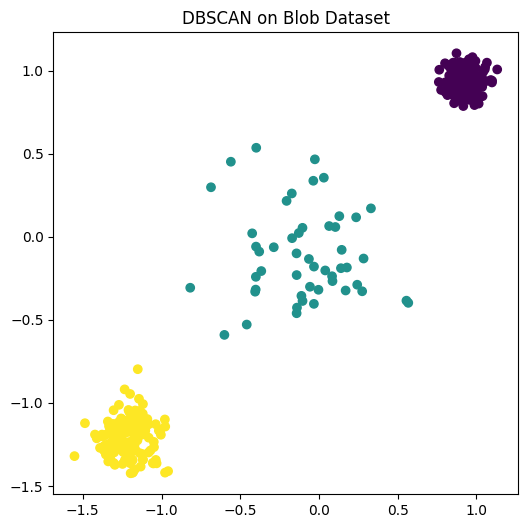

Unique labels (clusters + noise): {np.int64(0), np.int64(1), np.int64(2)}


In [3]:
from sklearn.cluster import DBSCAN

# TODO: Apply DBSCAN here
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_blobs_scaled)

plt.figure(figsize=(6,6))
plt.scatter(X_blobs_scaled[:,0], X_blobs_scaled[:,1], c=labels)
plt.title("DBSCAN on Blob Dataset")
plt.show()

print("Unique labels (clusters + noise):", set(labels))


### TODO 3: k-Distance Plot

Use a k-distance plot to estimate eps.


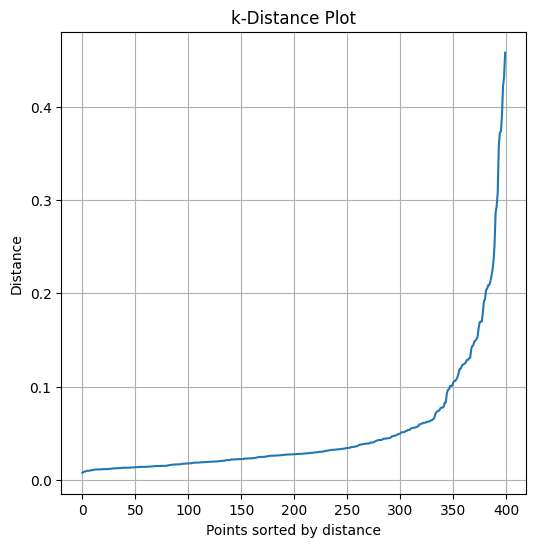

In [4]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# TODO: Create k-distance plot
k = 5  # same as min_samples
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_blobs_scaled)

distances, indices = neighbors.kneighbors(X_blobs_scaled)

# Sort distances
distances = np.sort(distances[:, k-1])

plt.figure(figsize=(6,6))
plt.plot(distances)
plt.title("k-Distance Plot")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance")
plt.grid()
plt.show()



## Dataset 2: Circular Dataset

This dataset contains non-linear circular clusters.


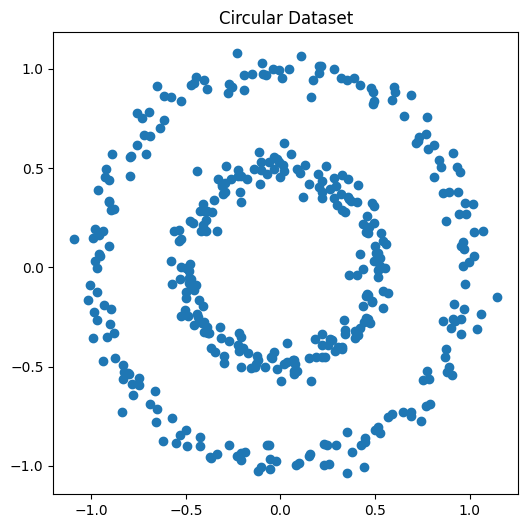

In [5]:
#Done for you
from sklearn.datasets import make_circles

X_circles, _ = make_circles(
    n_samples=400,
    factor=0.5,
    noise=0.05,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_circles[:,0], X_circles[:,1])
plt.title("Circular Dataset")
plt.show()


### TODO 4: DBSCAN on Circular Data

Apply DBSCAN and observe cluster shape.


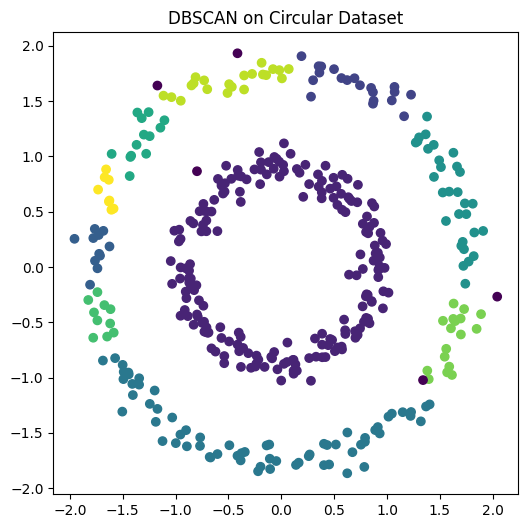

In [6]:
# TODO: Apply scaling and DBSCAN here
scaler = StandardScaler()
X_circles_scaled = scaler.fit_transform(X_circles)

dbscan_circles = DBSCAN(eps=0.2, min_samples=5)
labels_circles = dbscan_circles.fit_predict(X_circles_scaled)

plt.figure(figsize=(6,6))
plt.scatter(X_circles_scaled[:,0], X_circles_scaled[:,1], c=labels_circles)
plt.title("DBSCAN on Circular Dataset")
plt.show()



## Hierarchical Clustering Practice



### TODO 5: Agglomerative Clustering

Try different linkage methods:
single, complete, average, ward


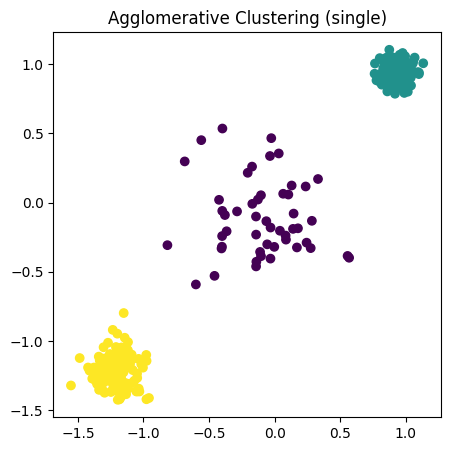

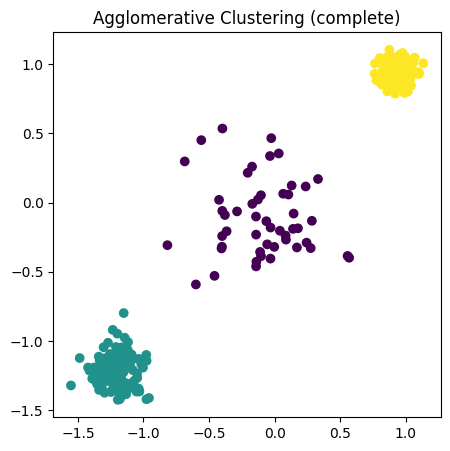

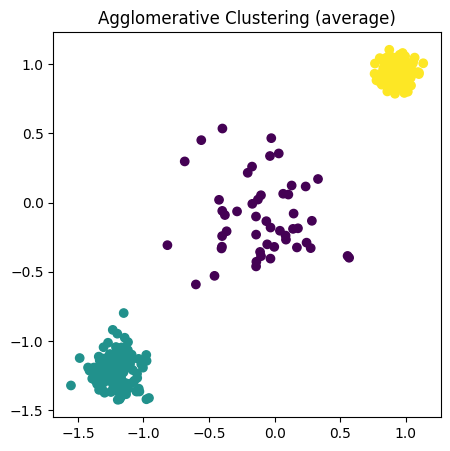

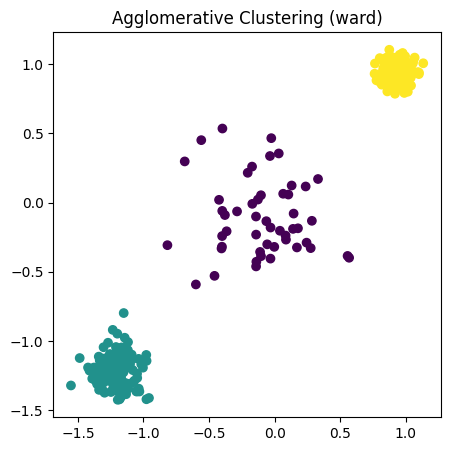

In [7]:
from sklearn.cluster import AgglomerativeClustering

linkages = ['single', 'complete', 'average', 'ward']

for link in linkages:
    model = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = model.fit_predict(X_blobs_scaled)

    plt.figure(figsize=(5,5))
    plt.scatter(X_blobs_scaled[:,0], X_blobs_scaled[:,1], c=labels)
    plt.title(f"Agglomerative Clustering ({link})")
    plt.show()



### TODO 6: Dendrogram

Create a dendrogram using Ward linkage.


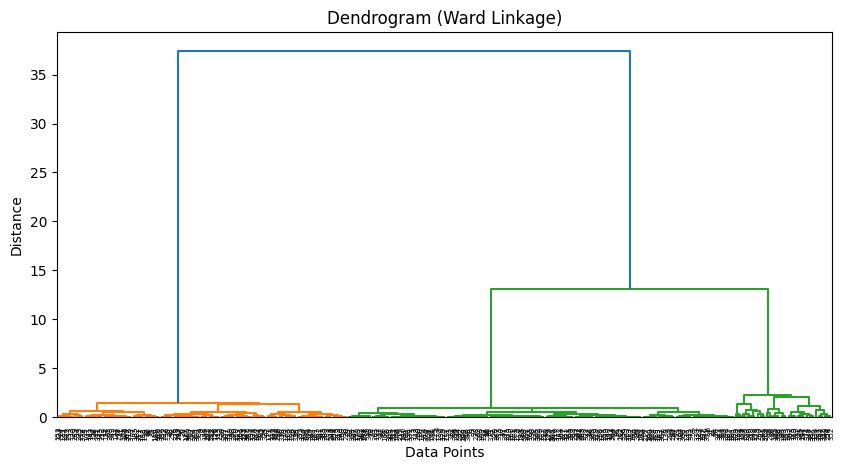

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage

# TODO: Create dendrogram here
Z = linkage(X_blobs_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()



## Reflection Questions

1. Which dataset suits DBSCAN better?
2. How does eps affect noise?
3. Which linkage feels most intuitive?
4. When would you prefer hierarchical clustering?


### Reflection

**1. Which dataset suits DBSCAN better?**  
The circular dataset suits DBSCAN better because it can detect non-linear cluster shapes, unlike many other clustering algorithms.

**2. How does eps affect noise?**  
Smaller eps → more points labeled as noise  
Larger eps → fewer noise points but risk of merging clusters

**3. Which linkage feels most intuitive?**  
Ward linkage is often most intuitive because it minimizes variance and creates balanced clusters.

**4. When would you prefer hierarchical clustering?**  
When you need a hierarchy of clusters, don’t know the number of clusters beforehand, or want interpretability via dendrograms.
